Fold 1 Training...
Epoch 1/50 - Train Loss: 0.3741, Train Dice: 0.8885 Val Loss: 0.2584, Val Dice: 0.9282, Val IoU: 0.8686, Val Precision: 0.9427, Val Recall: 0.9213
Current LR: 0.001
Epoch 2/50 - Train Loss: 0.2932, Train Dice: 0.9108 Val Loss: 0.2023, Val Dice: 0.9407, Val IoU: 0.8914, Val Precision: 0.9216, Val Recall: 0.9678
Current LR: 0.001
Epoch 3/50 - Train Loss: 0.2768, Train Dice: 0.9155 Val Loss: 0.1951, Val Dice: 0.9480, Val IoU: 0.9034, Val Precision: 0.9278, Val Recall: 0.9734
Current LR: 0.001
Epoch 4/50 - Train Loss: 0.2630, Train Dice: 0.9186 Val Loss: 0.2051, Val Dice: 0.9480, Val IoU: 0.9036, Val Precision: 0.9196, Val Recall: 0.9823
Current LR: 0.001
Epoch 5/50 - Train Loss: 0.2657, Train Dice: 0.9172 Val Loss: 0.1845, Val Dice: 0.9492, Val IoU: 0.9056, Val Precision: 0.9439, Val Recall: 0.9593
Current LR: 0.001
Epoch 6/50 - Train Loss: 0.2564, Train Dice: 0.9199 Val Loss: 0.1630, Val Dice: 0.9552, Val IoU: 0.9162, Val Precision: 0.9398, Val Recall: 0.9743
Current L

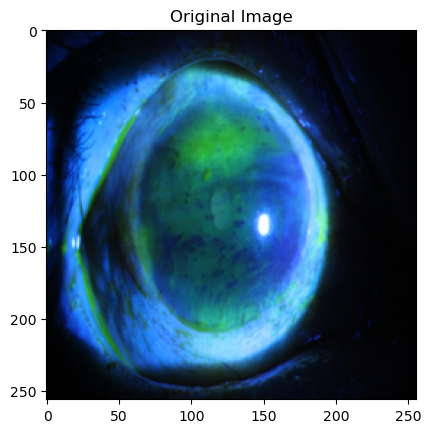

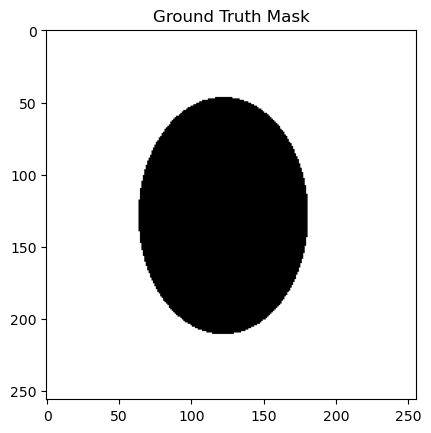

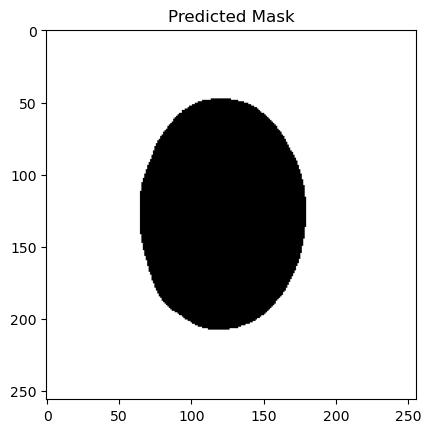

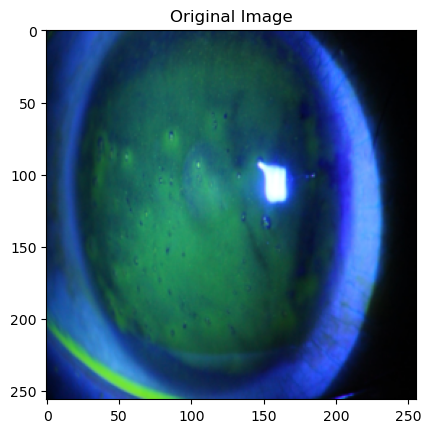

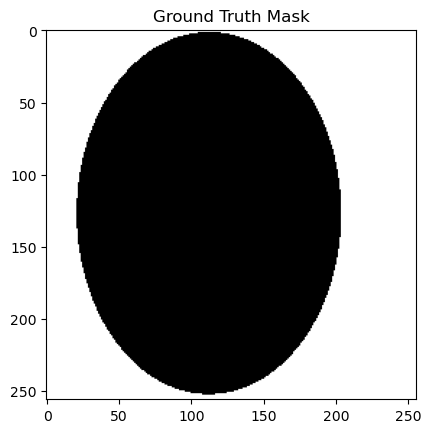

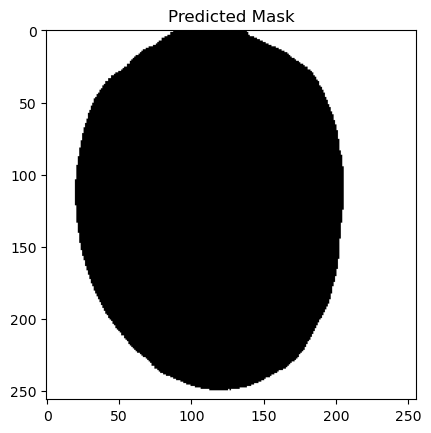

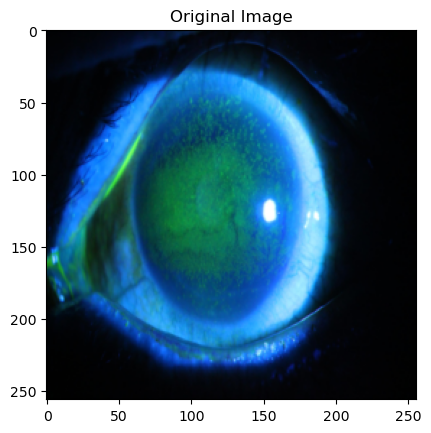

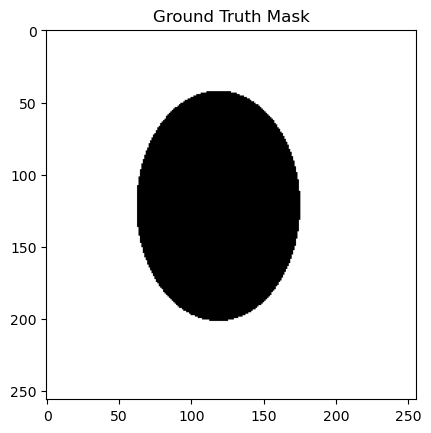

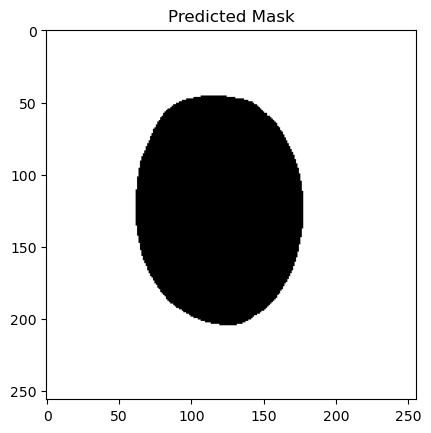

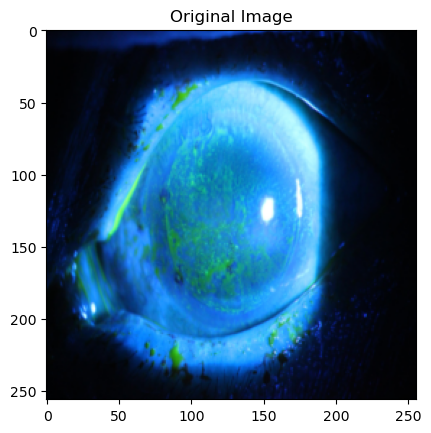

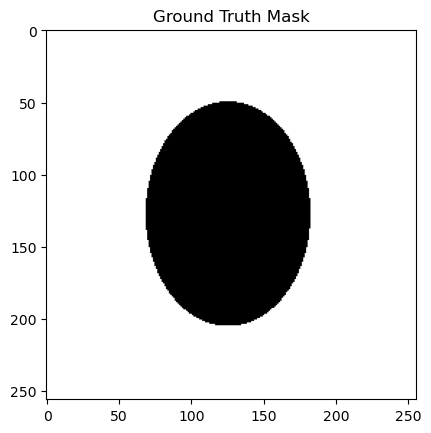

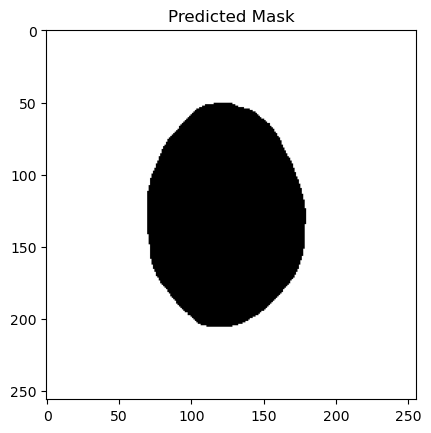

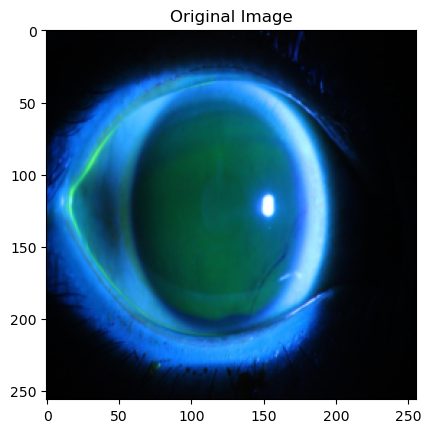

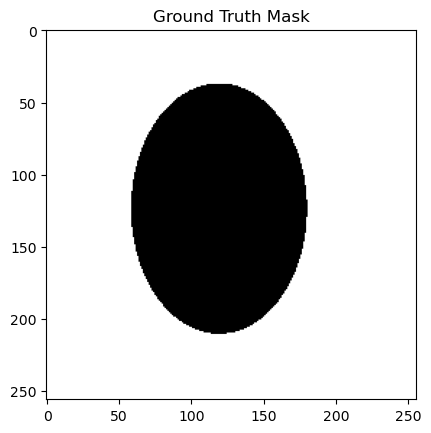

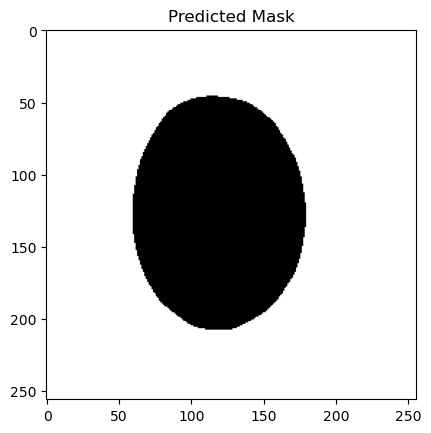

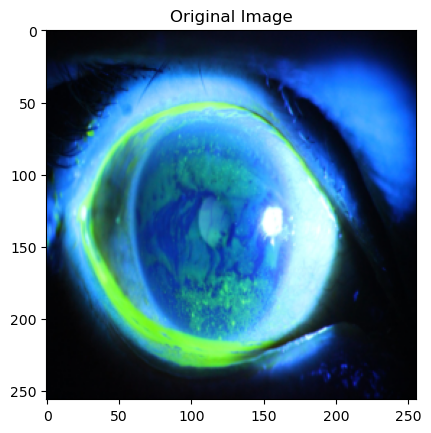

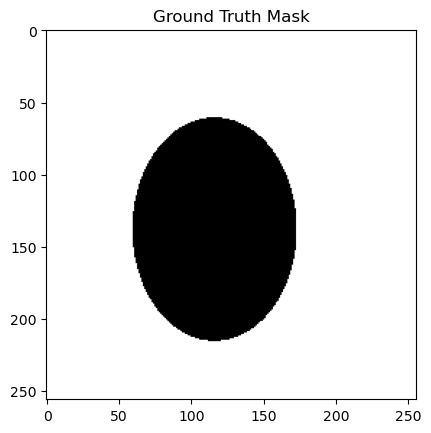

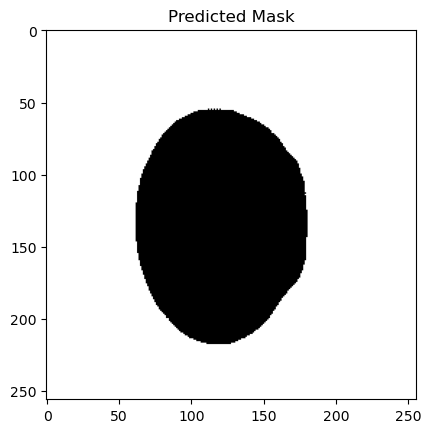

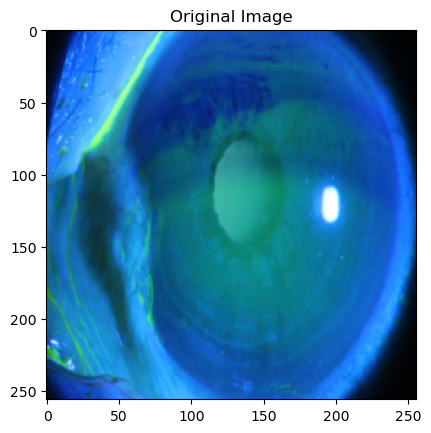

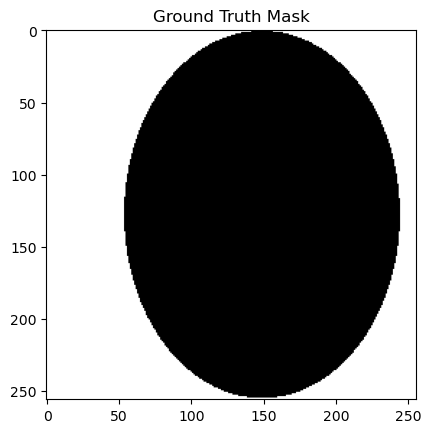

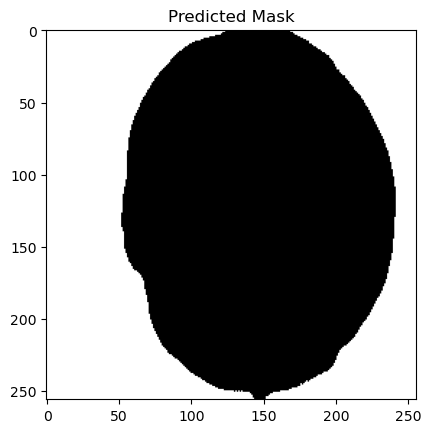

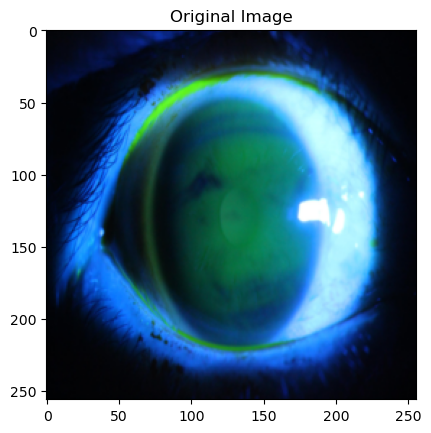

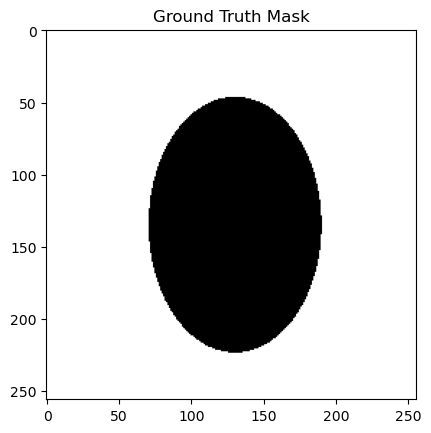

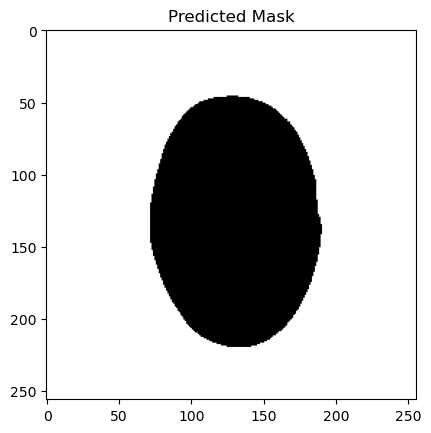

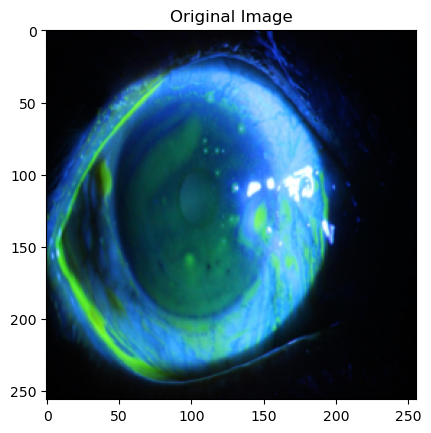

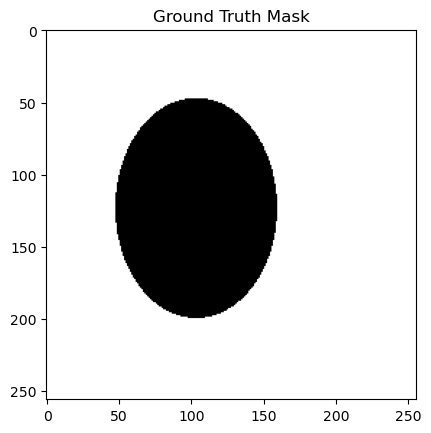

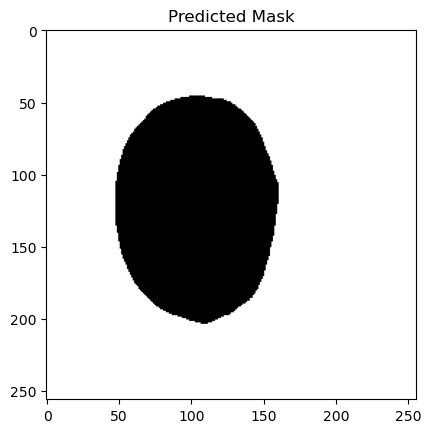

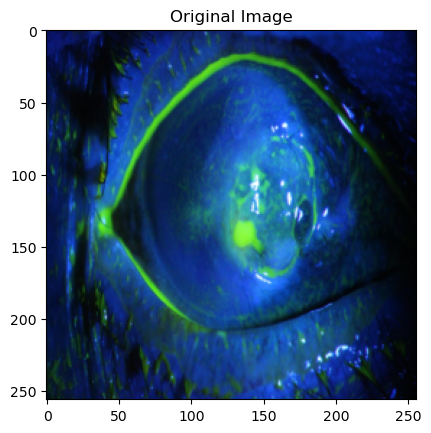

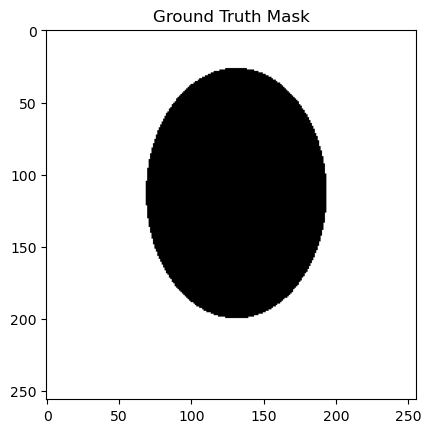

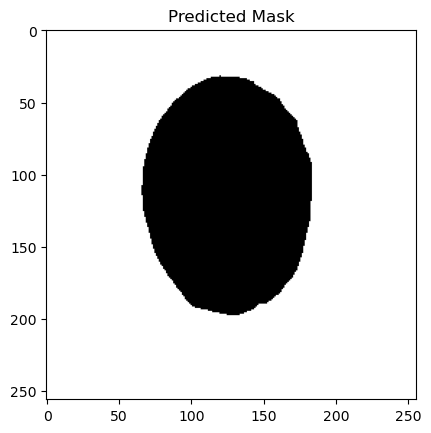

In [21]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# ======================
# 1) تابع محاسبه DICE
# ======================
def dice_coefficient(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + epsilon
    dice = (2.0 * intersection + epsilon) / union
    return dice.mean()

def iou_coefficient(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = (pred + target - pred * target).sum(dim=(1, 2, 3)) + epsilon
    iou = intersection / union
    return iou.mean()

def precision_score(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    tp = (pred * target).sum(dim=(1, 2, 3))
    fp = (pred * (1 - target)).sum(dim=(1, 2, 3)) + epsilon
    precision = tp / (tp + fp)
    return precision.mean()

def recall_score(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    tp = (pred * target).sum(dim=(1, 2, 3))
    fn = ((1 - pred) * target).sum(dim=(1, 2, 3)) + epsilon
    recall = tp / (tp + fn)
    return recall.mean()

# ======================
# 2) تنظیم seed
# ======================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ======================
# 3) تعریف دیتاست
# ======================
class CorneaDataset(Dataset):
    def __init__(self, images_list, masks_list, transform=None):
        self.images_list = images_list
        self.masks_list = masks_list
        self.transform = transform

    def __len__(self):
        return len(self.images_list)

    def __getitem__(self, idx):
        img_path = self.images_list[idx]
        mask_path = self.masks_list[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0.5).float()

        return image, mask

# ======================
# 4) آدرس فولدر تصاویر و ماسک‌ها
# ======================
images_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\segment\images"
labels_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\segment\corneaLabels"

images_list = sorted(glob.glob(os.path.join(images_dir, "*.*")))
masks_list = sorted(glob.glob(os.path.join(labels_dir, "*.*")))
assert len(images_list) == len(masks_list), "تعداد تصاویر با ماسک‌ها برابر نیست."

# ======================
# 5) تقسیم داده‌ها برای K-Fold Cross Validation
# ======================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================
# 6) تعریف ترنسفورم‌ها
# ======================
transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

transform_train_base = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

transform_train_aug = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor()
])
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[16, 32, 64, 128]):
        super(AttentionUNet, self).__init__()
        self.encoder1 = self.conv_block(in_channels, features[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder2 = self.conv_block(features[0], features[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder3 = self.conv_block(features[1], features[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder4 = self.conv_block(features[2], features[3])
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = self.conv_block(features[3], features[3]*2)

        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=features[3], F_l=features[3], F_int=features[3]//2)
        self.decoder4 = self.decoder_conv_block(features[3]*2, features[3])

        self.up3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=features[2], F_l=features[2], F_int=features[2]//2)
        self.decoder3 = self.decoder_conv_block(features[2]*2, features[2])

        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=features[1], F_l=features[1], F_int=features[1]//2)
        self.decoder2 = self.decoder_conv_block(features[1]*2, features[1])

        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=features[0], F_l=features[0], F_int=features[0]//2)
        self.decoder1 = self.decoder_conv_block(features[0]*2, features[0])

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def decoder_conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        p1 = self.pool1(e1)

        e2 = self.encoder2(p1)
        p2 = self.pool2(e2)

        e3 = self.encoder3(p2)
        p3 = self.pool3(e3)

        e4 = self.encoder4(p3)
        p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        up4 = self.up4(b)
        att4 = self.att4(g=up4, x=e4)
        d4 = torch.cat([up4, att4], dim=1)
        d4 = self.decoder4(d4)

        up3 = self.up3(d4)
        att3 = self.att3(g=up3, x=e3)
        d3 = torch.cat([up3, att3], dim=1)
        d3 = self.decoder3(d3)

        up2 = self.up2(d3)
        att2 = self.att2(g=up2, x=e2)
        d2 = torch.cat([up2, att2], dim=1)
        d2 = self.decoder2(d2)

        up1 = self.up1(d2)
        att1 = self.att1(g=up1, x=e1)
        d1 = torch.cat([up1, att1], dim=1)
        d1 = self.decoder1(d1)

        out = self.final_conv(d1)
        return out
# ======================
# 8) حلقه K-Fold Cross Validation با Learning Rate Scheduler
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 4
num_epochs = 50

fold_index = 1
all_dice = []
all_iou = []
all_precision = []
all_recall = []

for train_index, val_index in kf.split(images_list):
    print(f"Fold {fold_index} Training...")

    train_images = [images_list[i] for i in train_index]
    train_masks = [masks_list[i] for i in train_index]
    val_images = [images_list[i] for i in val_index]
    val_masks = [masks_list[i] for i in val_index]

    train_dataset_base = CorneaDataset(train_images, train_masks, transform=transform_train_base)
    train_dataset_aug = CorneaDataset(train_images, train_masks, transform=transform_train_aug)
    train_dataset = ConcatDataset([train_dataset_base, train_dataset_aug])

    val_dataset = CorneaDataset(val_images, val_masks, transform=transform_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = AttentionUNet(in_channels=3, out_channels=1).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # استفاده از Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            dice = dice_coefficient(outputs, masks).item()
            train_loss += loss.item()
            train_dice += dice

        train_loss /= len(train_loader)
        train_dice /= len(train_loader)

        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0
        val_precision = 0.0
        val_recall = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                dice = dice_coefficient(outputs, masks).item()
                iou = iou_coefficient(outputs, masks).item()
                precision = precision_score(outputs, masks).item()
                recall = recall_score(outputs, masks).item()

                val_loss += loss.item()
                val_dice += dice
                val_iou += iou
                val_precision += precision
                val_recall += recall

        val_loss /= len(val_loader)
        val_dice /= len(val_loader)
        val_iou /= len(val_loader)
        val_precision /= len(val_loader)
        val_recall /= len(val_loader)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} "
              f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}, "
              f"Val IoU: {val_iou:.4f}, Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}")
        print(f"Current LR: {optimizer.param_groups[0]['lr']}")

        # اعمال تغییرات به نرخ یادگیری
        scheduler.step(val_loss)
        
    model_save_path = f"attention_unet_fold_{fold_index}.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Saved model for fold {fold_index} at {model_save_path}")

    all_dice.append(val_dice)
    all_iou.append(val_iou)
    all_precision.append(val_precision)
    all_recall.append(val_recall)

    fold_index += 1

# ======================
# 9) نتایج K-Fold
# ======================
print("\n======= Cross Validation Results =======")
print(f"Avg Dice: {np.mean(all_dice):.4f}")
print(f"Avg IoU: {np.mean(all_iou):.4f}")
print(f"Avg Precision: {np.mean(all_precision):.4f}")
print(f"Avg Recall: {np.mean(all_recall):.4f}")

# ======================
# 10) انتخاب 10 تصویر تصادفی از داده‌های تست و نمایش نتایج
# ======================
test_dataset = CorneaDataset(images_list, masks_list, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()

sample_indices = random.sample(range(len(test_dataset)), 10)

for idx in sample_indices:
    image, mask = test_dataset[idx]
    image = image.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)

    output_sig = torch.sigmoid(output)
    output_bin = (output_sig > 0.5).float()

    image_np = image.squeeze().cpu().numpy().transpose(1, 2, 0)
    mask_np = mask.squeeze().cpu().numpy()
    output_np = output_bin.squeeze().cpu().numpy()

    # نمایش تصویر اصلی
    plt.imshow(image_np)
    plt.title("Original Image")
    plt.show()

    # نمایش ماسک واقعی
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.show()

    # نمایش پیش‌بینی ماسک
    plt.imshow(output_np, cmap="gray")
    plt.title("Predicted Mask")
    plt.show()

# ======================
# 11) ذخیره مدل نهایی
# ======================
# torch.save(model.state_dict(), "attention_unet_final.pth")        